In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



1. Load Data

In [9]:
# Membaca dataset awal
df = pd.read_csv('DatasetPerformaSiswa.csv')

print("--- INFO DATA AWAL ---")
print(df.info())
print("\nJumlah Missing Values per Kolom:")
print(df.isnull().sum())

--- INFO DATA AWAL ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence           

2. HANDLING MISSING VALUES (IMPUTASI)

In [10]:
# Mengidentifikasi kolom kategorikal yang memiliki data kosong
# Temuan: Teacher_Quality, Parental_Education_Level, Distance_from_Home memiliki nulls
cols_with_nulls = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']

for col in cols_with_nulls:
    # Mengisi dengan nilai Modus (nilai terbanyak)
    modus = df[col].mode()[0]
    df[col] = df[col].fillna(modus)
    print(f"Mengisi {col} dengan modus: {modus}")

Mengisi Teacher_Quality dengan modus: Medium
Mengisi Parental_Education_Level dengan modus: High School
Mengisi Distance_from_Home dengan modus: Near


3. HANDLING DATA TIDAK WAJAR (OUTLIERS)

In [11]:
# Temuan: Ada skor 101 pada Exam_Score (seharusnya max 100)
invalid_scores = df[df['Exam_Score'] > 100]
print(f"\nJumlah data dengan skor > 100: {len(invalid_scores)}")

# Melakukan capping agar nilai maksimal tetap 100
df.loc[df['Exam_Score'] > 100, 'Exam_Score'] = 100


Jumlah data dengan skor > 100: 1


4. PENGECEKAN DUPLIKAT

In [12]:
duplicate_count = df.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate_count}")
# Jika ada duplikat, kita hapus
df = df.drop_duplicates()

Jumlah data duplikat: 0


5. VISUALISASI PENDUKUNG

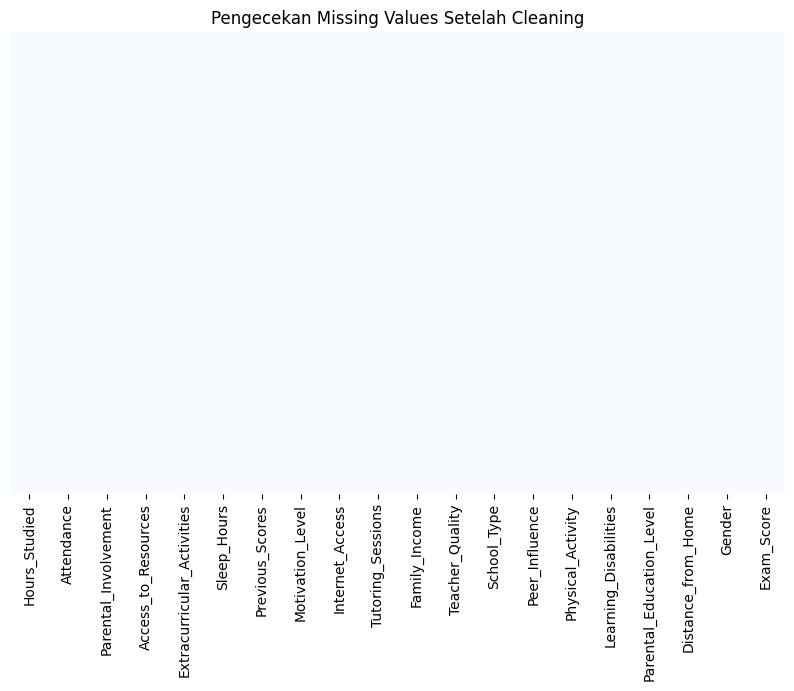

In [14]:
#A. Heatmap Missing Values (Setelah dibersihkan)
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='Blues')
plt.title('Pengecekan Missing Values Setelah Cleaning')
plt.show()

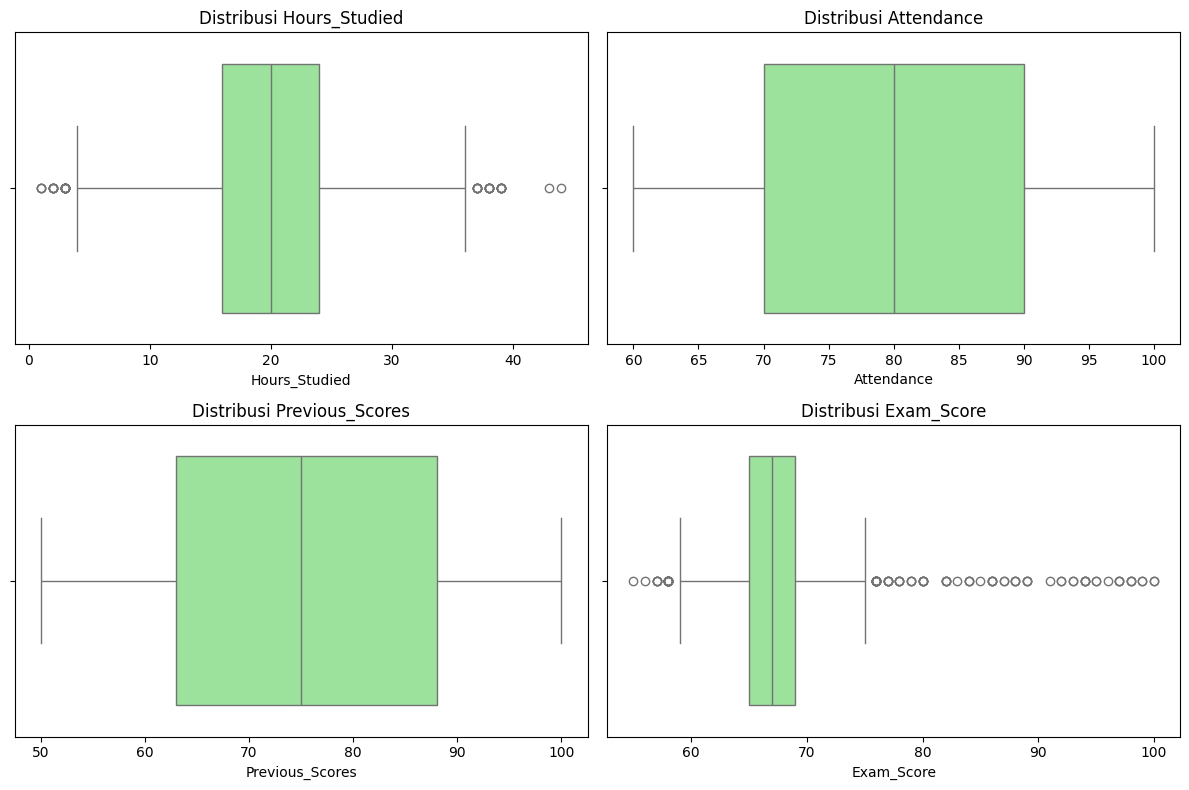

In [15]:
#B. Boxplot untuk analisis sebaran data numerik
numeric_cols = ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Exam_Score']
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

6. EXPORT DATA CLEANED

In [17]:
# Menyimpan hasil pembersihan untuk visualisasi di Tableau
df.to_csv('DatasetPerformaSiswa_Cleaned.csv', index=False)
print("\n--- PROSES SELESAI: Data telah diekspor ke 'DatasetPerformaSiswa_Cleaned.csv' ---")


--- PROSES SELESAI: Data telah diekspor ke 'DatasetPerformaSiswa_Cleaned.csv' ---
